# HEST coverage95 ??

?? notebook ?? `highconf_symbol95_rate` ??? test split ???????????????????? `results/hest1k_human_visium_expression/coverage95_diagnostics/`?

?????????slide-level test split?16,942 ? train coverage >=95% canonical gene symbols?mean-one slide-normalized size factor?count/rate ??? `count_i,g = rate_i,g * sf_i`?

## ????

???????? checkpoint?

- Expression model: `checkpoints/hest1k_human_visium_expression/highconf_symbol95_rate/best.pt`
- SF model: `checkpoints/hest1k_human_visium_sf/context_distribution_light_hipt256_leave_slide_out/best.pt`
- Config: `configs/hest1k_human_visium_expression_highconf_symbol95.yaml`
- Command: `python scripts\hest_coverage95_expression_diagnostics.py --splits test --batch-size 256`?? `histogene_bench` ??????

Notebook ???? 20 ??????????????????????????????

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

CWD = Path.cwd()
ROOT = CWD if (CWD / "configs").exists() else CWD.parent
OUT = ROOT / "results" / "hest1k_human_visium_expression" / "coverage95_diagnostics"

required = [
    OUT / "run_summary.json",
    OUT / "per_gene_metrics.csv",
    OUT / "per_slide_metrics.csv",
    OUT / "per_organ_metrics.csv",
    OUT / "gene_class_summary.csv",
    OUT / "spatial_overlay_manifest.csv",
    OUT / "sf_slide_metrics.csv",
    OUT / "sf_organ_metrics.csv",
]
missing = [str(path) for path in required if not path.exists()]
assert not missing, missing

summary = json.loads((OUT / "run_summary.json").read_text(encoding="utf-8"))
per_gene = pd.read_csv(OUT / "per_gene_metrics.csv")
per_slide = pd.read_csv(OUT / "per_slide_metrics.csv")
per_organ = pd.read_csv(OUT / "per_organ_metrics.csv")
gene_class = pd.read_csv(OUT / "gene_class_summary.csv")
overlays = pd.read_csv(OUT / "spatial_overlay_manifest.csv")
sf_slide = pd.read_csv(OUT / "sf_slide_metrics.csv")
sf_organ = pd.read_csv(OUT / "sf_organ_metrics.csv")

summary_overview = {
    "splits": summary["splits"],
    "n_spots": summary["n_spots"],
    "n_slides": summary["n_slides"],
    "n_genes": summary["n_genes"],
    "sf_overall": summary["sf_overall"],
    "expression_overall": summary["expression_overall"],
}
summary_overview

{'splits': ['test'],
 'n_spots': 121421,
 'n_slides': 48,
 'n_genes': 16942,
 'sf_overall': {'log_sf_pearson': 0.7859506686551935,
  'sf_pearson': 0.7190156576940735,
  'log_sf_mae': 0.5130715370178223,
  'log_sf_rmse': 0.7385206818580627,
  'sf_std_ratio': 0.82508332187833,
  'sf_top_decile_mean_ratio': 0.7234001378693943,
  'log_sf_top_decile_mae': 0.4974595606327057},
 'expression_overall': {'rate': {'mean_gene_pearson': 0.1583025976587336,
   'median_gene_pearson': 0.12675163971379758,
   'valid_genes': 16942},
  'count_no_sf': {'mean_gene_pearson': 0.32778755704692425,
   'median_gene_pearson': 0.3453921109709349,
   'valid_genes': 16942},
  'count_pred_sf': {'mean_gene_pearson': 0.3528979998607226,
   'median_gene_pearson': 0.37795418146783155,
   'valid_genes': 16942},
  'count_oracle_sf': {'mean_gene_pearson': 0.39760974888621825,
   'median_gene_pearson': 0.4297538926135209,
   'valid_genes': 16942}}}

## ????

`rate` ?? H&E ? size-factor ??????????`count_no_sf` ? rate ??? count?`count_pred_sf` ???? SF ?? count?`count_oracle_sf` ???? SF?????????? SF ???????

In [2]:
expr_rows = []
for metric, values in summary["expression_overall"].items():
    expr_rows.append({"target": metric, **values})
expr_summary = pd.DataFrame(expr_rows)

sf_summary = pd.DataFrame([{
    "target": "sf",
    **summary["sf_overall"],
}])

display(Markdown(f"**Test slides**: {summary['n_slides']} ?**spots**: {summary['n_spots']:,} ?**genes**: {summary['n_genes']:,}"))
display(sf_summary.round(4))
display(expr_summary.round(4))

**Test slides**: 48 ?**spots**: 121,421 ?**genes**: 16,942

,target,log_sf_pearson,sf_pearson,log_sf_mae,log_sf_rmse,sf_std_ratio,sf_top_decile_mean_ratio,log_sf_top_decile_mae
0,sf,0.786,0.719,0.5131,0.7385,0.8251,0.7234,0.4975


,target,mean_gene_pearson,median_gene_pearson,valid_genes
0,rate,0.1583,0.1268,16942
1,count_no_sf,0.3278,0.3454,16942
2,count_pred_sf,0.3529,0.3780,16942
3,count_oracle_sf,0.3976,0.4298,16942


## ?????

??? Pearson ?????????? H&E-to-ST ????? gene-wise spatial correlation??????? MAE/RMSE???/????????????????????????????????????????

In [3]:
cols = [
    "gene", "gene_class",
    "rate_pearson", "count_no_sf_pearson", "count_pred_sf_pearson", "count_oracle_sf_pearson",
    "count_pred_sf_mae", "count_pred_sf_rmse", "count_pred_sf_detected_fraction",
    "selection_slide_fraction", "selection_detected_fraction",
]
ranked = per_gene[cols].sort_values("count_pred_sf_pearson", ascending=False)

display(Markdown("**Top 15 genes by count_pred_sf Pearson**"))
display(ranked.head(15).round(4))

display(Markdown("**Bottom 15 measured genes by count_pred_sf Pearson**"))
display(ranked.tail(15).round(4))

**Top 15 genes by count_pred_sf Pearson**

,gene,gene_class,rate_pearson,count_no_sf_pearson,count_pred_sf_pearson,count_oracle_sf_pearson,count_pred_sf_mae,count_pred_sf_rmse,count_pred_sf_detected_fraction,selection_slide_fraction,selection_detected_fraction
525,MUC1,epithelial_tumor,0.8452,0.8480,0.9197,0.9511,2.6724,14.2518,0.2847,0.9939,0.3361
405,SLC12A2,other,0.6540,0.7810,0.8557,0.8467,1.4137,5.1378,0.3042,0.9939,0.3787
8906,LMOD1,other,0.6142,0.8182,0.8545,0.9093,0.4827,2.0426,0.1592,0.9877,0.1386
1482,GATA3,other,0.6700,0.7647,0.8539,0.8919,0.2968,1.4577,0.0879,0.9939,0.1239
5594,SYNPO2,other,0.6358,0.8228,0.8447,0.9114,0.7549,2.9187,0.2604,0.9877,0.2309
585,MYLK,other,0.6201,0.8002,0.8417,0.8816,1.1715,3.7266,0.3056,0.9939,0.3210
4659,STK38L,other,0.4014,0.7168,0.8402,0.8574,0.5112,1.6252,0.2209,0.9877,0.2652
6773,CKMT2,other,0.8159,0.8434,0.8355,0.9086,0.8480,2.9207,0.2215,0.9877,0.1968
12870,SLC6A19,other,0.3871,0.7834,0.8352,0.8897,0.0619,0.8317,0.0105,0.9877,0.0333
5878,CNN1,other,0.6011,0.7868,0.8327,0.8491,1.0713,3.0084,0.3129,0.9877,0.2226


**Bottom 15 measured genes by count_pred_sf Pearson**

,gene,gene_class,rate_pearson,count_no_sf_pearson,count_pred_sf_pearson,count_oracle_sf_pearson,count_pred_sf_mae,count_pred_sf_rmse,count_pred_sf_detected_fraction,selection_slide_fraction,selection_detected_fraction
15039,NUTM1,other,0.0378,0.0288,-0.0007,0.0020,0.0029,0.0396,0.0014,0.9877,0.0056
14115,AFP,other,0.0026,0.0072,-0.0009,0.0039,0.0064,0.0527,0.0025,0.9877,0.0132
16724,MAGEB4,other,0.0285,0.0197,-0.0009,-0.0004,0.0027,0.0330,0.0010,0.9693,0.0040
15105,TRPV5,other,0.0137,0.0023,-0.0015,-0.0002,0.0037,0.0469,0.0020,0.9877,0.0049
16501,OR4C11,other,-0.0018,-0.0030,-0.0031,-0.0015,0.0009,0.0258,0.0006,0.9755,0.0036
16149,KLK14,other,0.0038,-0.0034,-0.0033,-0.0037,0.0020,0.0412,0.0013,0.9816,0.0022
14126,MYL1,other,0.0264,0.0038,-0.0035,-0.0034,0.0175,0.1091,0.0037,0.9877,0.0131
16494,XKR5,other,0.0171,0.0021,-0.0035,0.0003,0.0028,0.0396,0.0015,0.9755,0.0040
15801,TRIM50,other,0.0191,0.0078,-0.0045,0.0003,0.0056,0.0489,0.0022,0.9816,0.0076
1197,CHI3L1,other,0.0109,0.0025,-0.0052,0.0029,0.9711,5.9968,0.1471,0.9939,0.1833


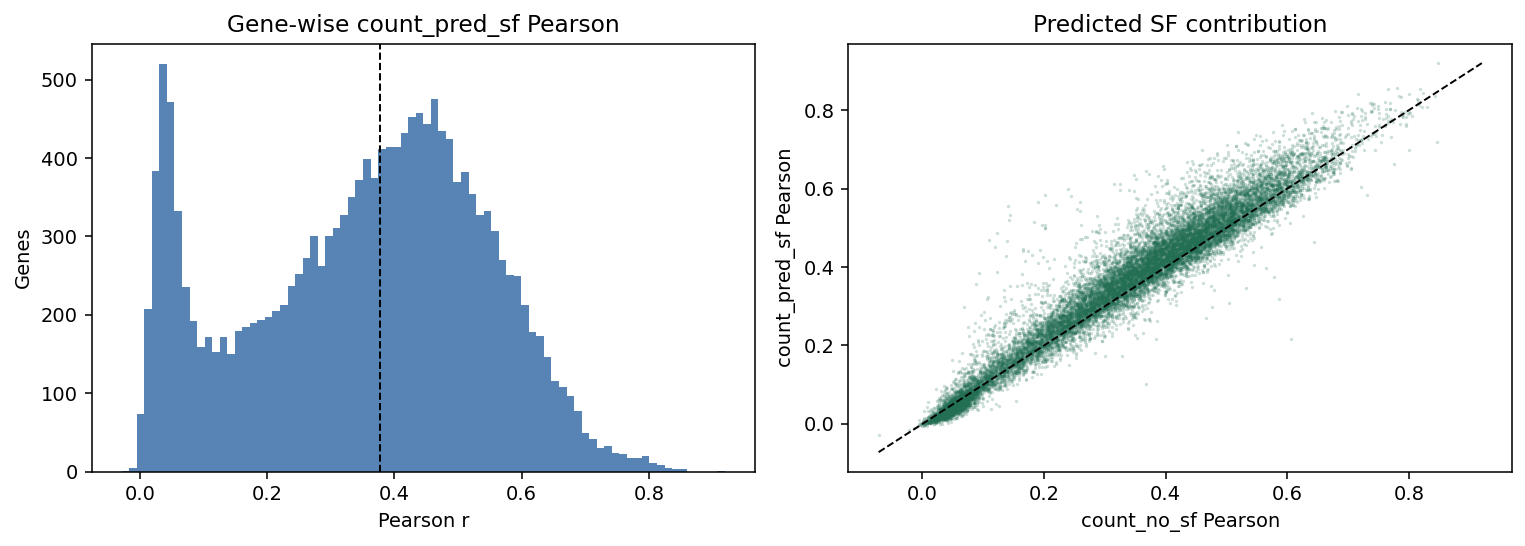

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=140)

axes[0].hist(per_gene["count_pred_sf_pearson"].dropna(), bins=80, color="#3b6ea8", alpha=0.85)
axes[0].axvline(per_gene["count_pred_sf_pearson"].median(), color="black", linestyle="--", linewidth=1)
axes[0].set_title("Gene-wise count_pred_sf Pearson")
axes[0].set_xlabel("Pearson r")
axes[0].set_ylabel("Genes")

axes[1].scatter(
    per_gene["count_no_sf_pearson"],
    per_gene["count_pred_sf_pearson"],
    s=3, alpha=0.22, color="#226f54", linewidths=0,
)
lo = np.nanmin([per_gene["count_no_sf_pearson"].min(), per_gene["count_pred_sf_pearson"].min()])
hi = np.nanmax([per_gene["count_no_sf_pearson"].max(), per_gene["count_pred_sf_pearson"].max()])
axes[1].plot([lo, hi], [lo, hi], color="black", linewidth=1, linestyle="--")
axes[1].set_title("Predicted SF contribution")
axes[1].set_xlabel("count_no_sf Pearson")
axes[1].set_ylabel("count_pred_sf Pearson")

fig.tight_layout()
plt.show()

## ?????

??????????????? marker panel ????? marker ?????/????????/ECM??????? housekeeping/stress genes???????????????????

,gene_class,n_genes,n_valid_count_pred_sf,mean_rate_pearson,median_rate_pearson,mean_count_no_sf_pearson,median_count_no_sf_pearson,mean_count_pred_sf_pearson,median_count_pred_sf_pearson,mean_count_oracle_sf_pearson,median_count_oracle_sf_pearson,mean_count_pred_sf_mae,median_count_pred_sf_mae,mean_count_pred_sf_rmse,median_count_pred_sf_rmse,mean_count_pred_sf_detected_fraction,median_count_pred_sf_detected_fraction
0,endothelial,6,6,0.1892,0.1629,0.2819,0.2627,0.3033,0.2781,0.3505,0.3343,0.6086,0.5726,1.6180,1.8467,0.2478,0.2263
1,epithelial_tumor,6,6,0.4607,0.4300,0.5180,0.5820,0.5387,0.6030,0.6220,0.6776,3.4285,1.8712,14.4442,9.1210,0.2454,0.2780
2,housekeeping_stress,8,8,0.3608,0.3387,0.3898,0.3377,0.4415,0.4565,0.5308,0.5484,9.4322,10.2020,26.1612,26.8998,0.7010,0.8113
3,immune,10,10,0.1817,0.1386,0.3185,0.3335,0.2636,0.2544,0.3175,0.2934,0.5456,0.1731,2.2626,0.6357,0.1181,0.0851
4,other,16899,16899,0.1579,0.1265,0.3276,0.3453,0.3527,0.3779,0.3974,0.4297,0.3139,0.1842,0.9393,0.4886,0.1325,0.1022
5,proliferation,5,5,0.2685,0.2642,0.4750,0.4910,0.4338,0.4392,0.4714,0.4722,0.4141,0.4130,1.3998,1.5602,0.1529,0.1507
6,stromal_ecm,8,8,0.4447,0.4360,0.4762,0.5283,0.5603,0.5526,0.5885,0.5642,14.8746,12.2721,62.9077,37.1719,0.5388,0.5356


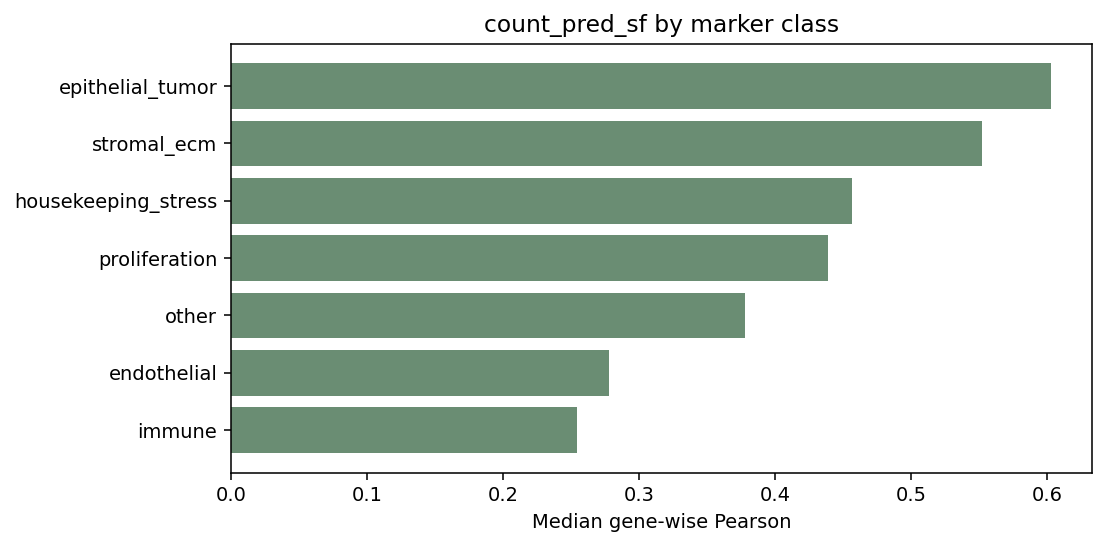

In [5]:
display(gene_class.round(4))

plot_df = gene_class.sort_values("median_count_pred_sf_pearson", ascending=True)
fig, ax = plt.subplots(figsize=(8, 4), dpi=140)
ax.barh(plot_df["gene_class"], plot_df["median_count_pred_sf_pearson"], color="#6a8d73")
ax.set_xlabel("Median gene-wise Pearson")
ax.set_title("count_pred_sf by marker class")
fig.tight_layout()
plt.show()

## ???????

?????/???? flattened spot-gene ???????????????????????????????????? leave-organ-out ? leave-cohort-out?

,metric,n_values,pearson,mae,rmse,true_mean,pred_mean,true_std,pred_std,split,organ,level
14,count_pred_sf,4195691,0.8746,0.4928,3.3732,0.7710,0.6825,5.9849,6.9522,test,Breast,organ
16,count_pred_sf,470974522,0.6786,0.2263,2.3878,0.2441,0.1865,3.2463,2.3118,test,Heart,organ
15,count_pred_sf,21065634,0.6195,0.3236,3.0106,0.3833,0.1970,3.6333,1.3049,test,Eye,organ
17,count_pred_sf,213536968,0.6042,0.2028,6.2423,0.2030,0.1553,7.6767,3.3945,test,Skin,organ
13,count_pred_sf,499029679,0.5604,0.2089,1.2589,0.1969,0.1492,1.4798,1.1130,test,Brain,organ
12,count_pred_sf,721160906,0.3107,0.5122,7.2616,0.5659,0.3390,7.5240,3.5764,test,Bowel,organ


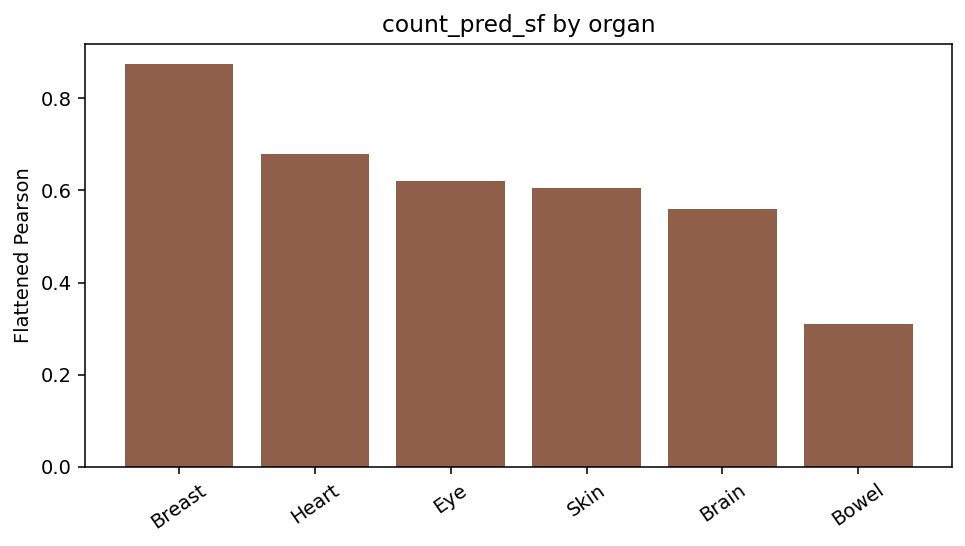

**Lowest 10 slides by flattened count_pred_sf Pearson**

,metric,n_values,pearson,mae,rmse,true_mean,pred_mean,true_std,pred_std,split,sample_id,organ,cohort,disease_state,level
98,count_pred_sf,20347342,0.1513,0.3778,2.9768,0.3007,0.1710,3.0074,0.3708,test,MEND66,Brain,Spatially resolved transcriptomic profiling of...,Cancer,slide
132,count_pred_sf,9250332,0.2308,0.1128,2.3600,0.0611,0.0932,2.4231,0.6608,test,NCBI517,Skin,Spatial transcriptomics landscape of non-commu...,Diseased,slide
119,count_pred_sf,42729528,0.2410,1.4757,9.5413,1.6555,0.4417,8.9377,5.9376,test,MISC67,Bowel,COLON MAP: Colon Molecular Atlas Project,Cancer,slide
127,count_pred_sf,10453214,0.2424,0.0894,1.2966,0.0223,0.0896,0.5920,1.3040,test,NCBI490,Skin,Spatial transcriptomics landscape of non-commu...,Diseased,slide
96,count_pred_sf,55451166,0.2676,0.2292,10.1280,0.2610,0.1479,10.4577,1.7827,test,MEND35,Bowel,"Human ileum, Visium",Healthy,slide
118,count_pred_sf,66730806,0.3802,0.8294,8.4527,0.9664,0.4337,6.8065,8.2037,test,MISC66,Bowel,COLON MAP: Colon Molecular Atlas Project,Cancer,slide
117,count_pred_sf,21763170,0.3894,0.4936,3.0688,0.2977,0.4781,1.8165,3.2736,test,MISC59,Bowel,COLON MAP: Colon Molecular Atlas Project,Tumor,slide
99,count_pred_sf,18026288,0.4336,0.1877,1.8867,0.1634,0.1099,2.0559,0.5384,test,MEND92,Bowel,Spatially resolved transcriptomic profiling of...,Healthy,slide
141,count_pred_sf,100549617,0.4381,0.4976,14.1758,0.6887,0.3795,15.1760,2.8077,test,TENX91,Bowel,Visium CytAssist Gene Expression Libraries of ...,Cancer,slide
143,count_pred_sf,17755216,0.4499,0.3540,1.8781,0.3105,0.3211,1.3924,2.0339,test,ZEN44,Bowel,Charting the Heterogeneity of Colorectal Cance...,Cancer,slide


**Highest 10 slides by flattened count_pred_sf Pearson**

,metric,n_values,pearson,mae,rmse,true_mean,pred_mean,true_std,pred_std,split,sample_id,organ,cohort,disease_state,level
137,count_pred_sf,4195691,0.8746,0.4928,3.3732,0.7710,0.6825,5.9849,6.9522,test,TENX23,Breast,"Human Breast Cancer: Targeted, Immunology Panel",Cancer,slide
109,count_pred_sf,67345488,0.8350,0.3311,2.3401,0.3769,0.3869,3.8897,4.1945,test,MISC129,Heart,Spatially resolved multiomics of human cardiac...,Healthy,slide
110,count_pred_sf,59774202,0.7714,0.4020,3.0504,0.5255,0.3396,4.7660,3.9424,test,MISC130,Heart,Spatially resolved multiomics of human cardiac...,Healthy,slide
139,count_pred_sf,3967497,0.7664,0.5309,2.1745,0.6512,0.5945,3.3150,2.9779,test,TENX30,Brain,"Human Glioblastoma: Targeted, Pan-Cancer Panel",Cancer,slide
107,count_pred_sf,56738758,0.7508,0.1413,0.7995,0.1355,0.0934,1.1779,0.7052,test,MISC125,Heart,Spatially resolved multiomics of human cardiac...,Healthy,slide
134,count_pred_sf,61313098,0.7440,0.3400,1.7020,0.3631,0.2592,2.5240,1.6738,test,NCBI629,Brain,Spatial transcriptomics reveal unnresolved wou...,Cancer,slide
111,count_pred_sf,61939952,0.7428,0.2197,0.7591,0.2356,0.0979,1.0034,0.4198,test,MISC3,Brain,spatialLIBD,Healthy,slide
108,count_pred_sf,75917102,0.7220,0.1749,1.3788,0.1830,0.0743,1.7594,0.6320,test,MISC126,Heart,Spatially resolved multiomics of human cardiac...,Healthy,slide
138,count_pred_sf,84489754,0.6983,0.2481,0.7835,0.2510,0.1891,1.0763,0.6228,test,TENX27,Brain,Human Cerebellum: Whole Transcriptome Analysis,Healthy,slide
126,count_pred_sf,9894128,0.6980,0.0810,0.6295,0.0428,0.0868,0.7425,0.8523,test,NCBI489,Skin,Spatial transcriptomics landscape of non-commu...,Diseased,slide


In [6]:
organ_count = per_organ[per_organ["metric"].eq("count_pred_sf")].sort_values("pearson", ascending=False)
display(organ_count.round(4))

fig, ax = plt.subplots(figsize=(7, 4), dpi=140)
ax.bar(organ_count["organ"], organ_count["pearson"], color="#8f5f4a")
ax.set_ylabel("Flattened Pearson")
ax.set_title("count_pred_sf by organ")
ax.tick_params(axis="x", rotation=35)
fig.tight_layout()
plt.show()

slide_count = per_slide[per_slide["metric"].eq("count_pred_sf")].copy()
display(Markdown("**Lowest 10 slides by flattened count_pred_sf Pearson**"))
display(slide_count.sort_values("pearson").head(10).round(4))
display(Markdown("**Highest 10 slides by flattened count_pred_sf Pearson**"))
display(slide_count.sort_values("pearson", ascending=False).head(10).round(4))

## Spatial overlays

?? overlay ??? test slide `MISC33` ????? marker genes ?????????? `count_pred_sf` ?????????? count??? count?????? SF ???????????????????????? SF/???????

,sample_id,gene,gene_index,gene_class,selection_reason,count_pred_sf_pearson,written
0,MISC33,KRT7,10569,epithelial_tumor,poor_count_pred_sf,0.130100,True
1,MISC33,CD8A,1749,immune,poor_count_pred_sf,0.157225,True
2,MISC33,ACTB,1912,housekeeping_stress,median_count_pred_sf,0.387217,True
3,MISC33,MUC1,525,epithelial_tumor,good_count_pred_sf,0.919718,True
4,MISC33,COL1A1,201,stromal_ecm,good_count_pred_sf,0.727224,True
5,MISC33,EPCAM,3229,epithelial_tumor,good_count_pred_sf,0.692843,True


**good_count_pred_sf**: `MUC1` (epithelial_tumor), r=0.920

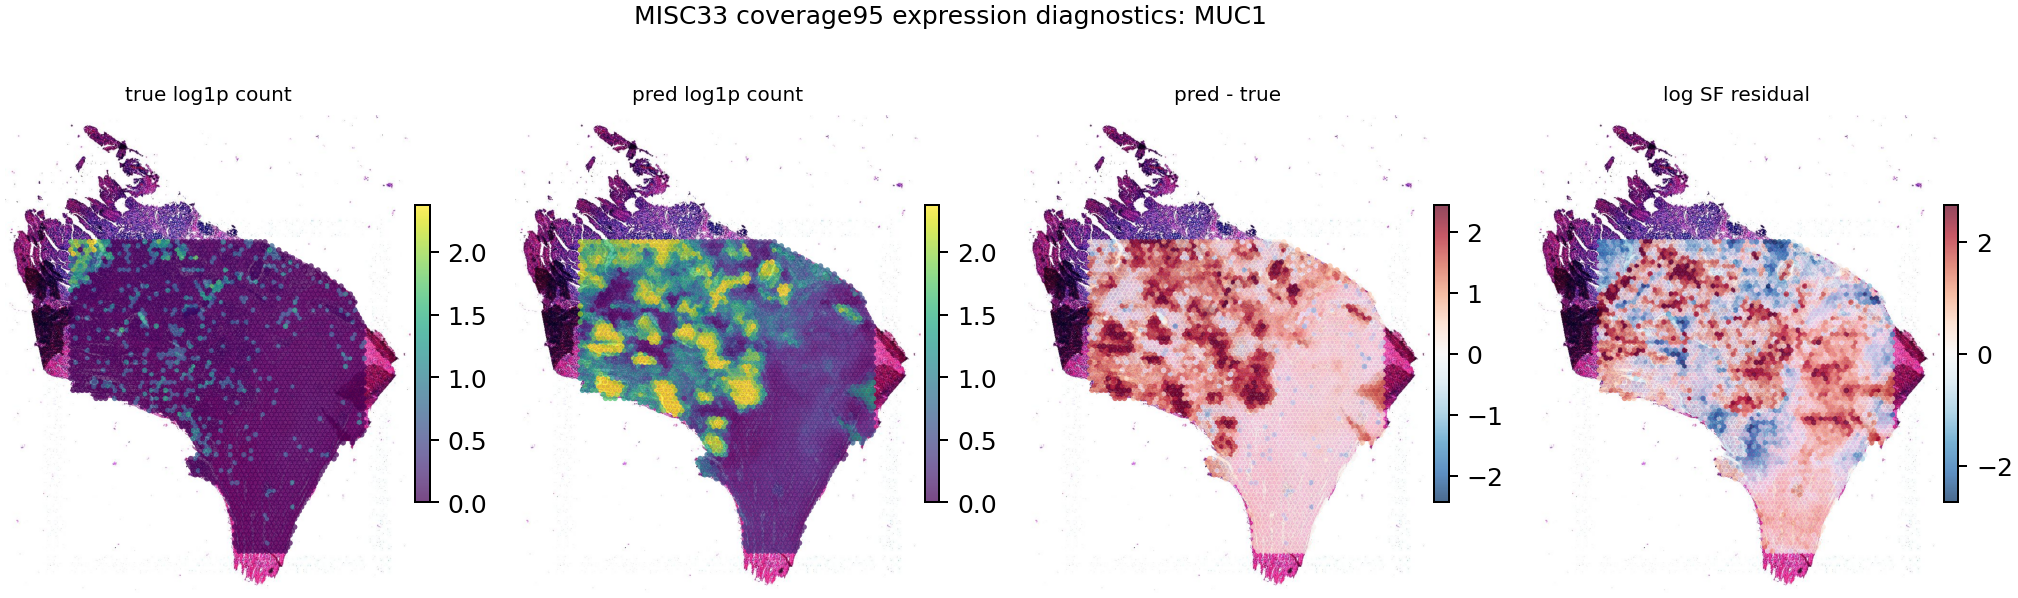

**median_count_pred_sf**: `ACTB` (housekeeping_stress), r=0.387

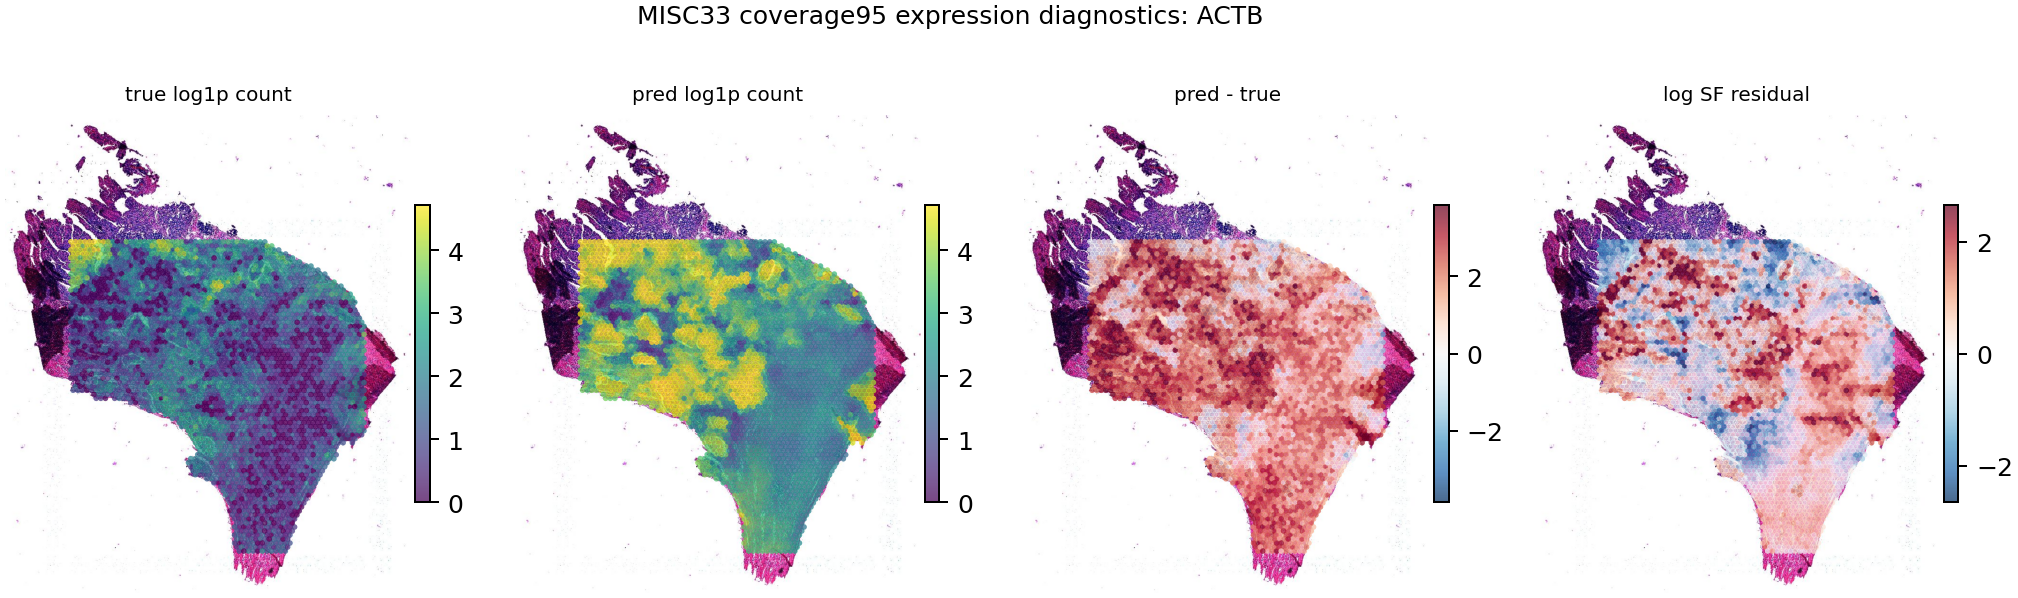

**poor_count_pred_sf**: `KRT7` (epithelial_tumor), r=0.130

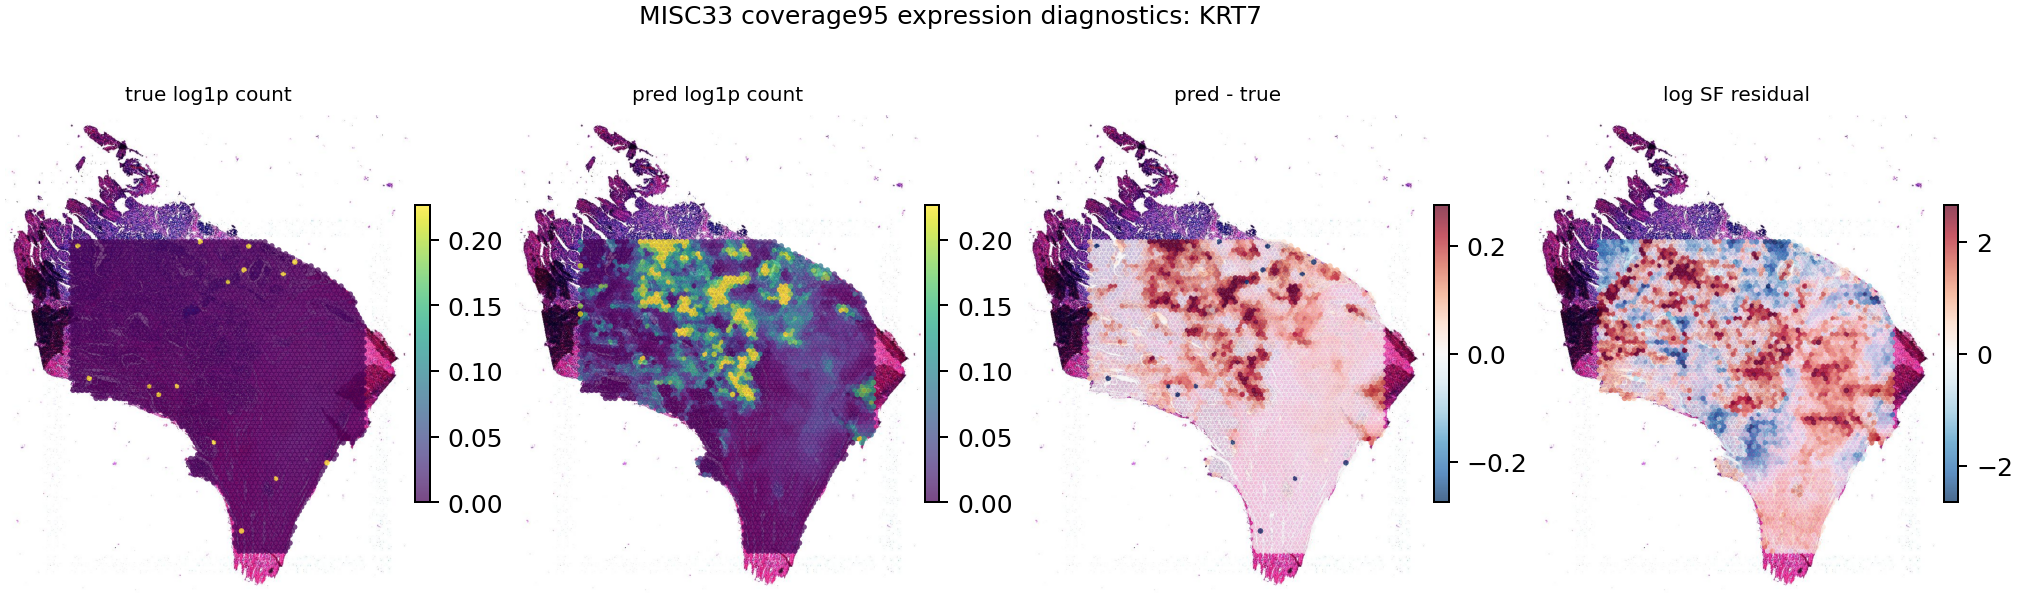

In [7]:
display(overlays.drop(columns=["path"], errors="ignore"))

selected_for_display = []
for reason in ["good_count_pred_sf", "median_count_pred_sf", "poor_count_pred_sf"]:
    frame = overlays[overlays["selection_reason"].eq(reason)]
    if not frame.empty:
        selected_for_display.append(frame.iloc[0])

for row in selected_for_display:
    display(Markdown(f"**{row['selection_reason']}**: `{row['gene']}` ({row['gene_class']}), r={row['count_pred_sf_pearson']:.3f}"))
    display(Image(filename=str(Path(row["path"]))))

## ????

1. SF ??????? combined test?`log_sf_pearson=0.786`?`sf_pearson=0.719`???????????? SF ???
2. ? 16,942 ? coverage95 genes?`count_pred_sf` ? mean gene-wise Pearson ? 0.353??? `count_no_sf` ? 0.328?`count_oracle_sf` ? 0.398????????????? SF ??????????????
3. Marker ???? epithelial/tumor?stromal/ECM?proliferation ?????immune/endothelial ?????? H&E ??????????????? marker panel ? cell-type enrichment ???
4. ???? flattened ????????????????????????????????????? benchmark ???leave-organ-out??????????